# ทดสอบและทำนายผลตัวอักษรไทย (Inference - Top-1)
### โครงงานจำแนกตัวอักษรและตัวเลขภาษาไทย 72 คลาส ด้วย ResNet-18


In [1]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18
import torchvision.transforms.functional as TF

plt.rcParams['font.family'] = 'Tahoma'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 1. โครงสร้าง ResNet-18 (Transfer Learning 72 คลาส)
def build_model(num_classes=72):
    model = resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

# 2. แปลงรหัสคลาส (TIS-620) เป็นตัวอักษรภาษาไทย
def get_thai_char(c):
    try:
        return bytes([int(c)]).decode('tis-620')
    except Exception:
        return str(c)

# 3. โหลดโมเดล model.pt (โหลดน้ำหนักและคลาสจากตัว model.pt โดยตรง )
checkpoint = torch.load('model.pt', map_location=device)
sd = checkpoint.get('model_state_dict', checkpoint)

classes = [str(c) for c in checkpoint.get('classes', [str(i) for i in range(161, 250)])]
idx_to_class = {i: str(c) for i, c in enumerate(classes)}
classes_str = set(classes)

model = build_model(num_classes=len(classes))
model.load_state_dict({k.replace('backbone.', ''): v for k, v in sd.items()})
model = model.to(device)
model.eval()

# 4. Data Transform (ดึงขนาดจากโมเดล เช่น 64x64)
img_size = checkpoint.get('img_size', 64)
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print(f'โหลดโมเดลสำเร็จ! (Image Size: {img_size}x{img_size}, Classes: {len(classes)})')


Using device: cuda:0
โหลดโมเดลสำเร็จ! (Image Size: 64x64, Classes: 72)


## 1. ฟังก์ชันทำนายภาพเดี่ยว (Single Image Prediction)


ไฟล์: synth_233_angsana_formal.png -> ตัวอักษร: ้ | รหัสคลาส: 233 | ความมั่นใจ: 98.57%


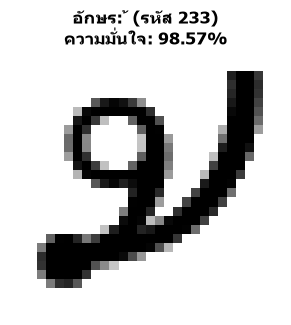

{'code': '233', 'char': '้', 'confidence': 98.56969714164734}

In [2]:
def predict_image(img_path, show=True):
    if not os.path.exists(img_path):
        print(f'ไม่พบไฟล์: {img_path}')
        return None
        
    img = Image.open(img_path).convert('RGB')
    
    # คำนวณผลพร้อม TTA หมุน -5, 0, 5 องศา (เติมขอบขาว 255 บนภาพต้นฉบับก่อน Normalize เพื่อป้องกันขอบสีเทา)
    tensors = [
        transform(img.rotate(angle, fillcolor=(255, 255, 255), resample=Image.BILINEAR)).unsqueeze(0).to(device)
        for angle in [-5, 0, 5]
    ]
    batch_x = torch.cat(tensors, dim=0)
    
    with torch.no_grad():
        probs = torch.softmax(model(batch_x), dim=1).mean(dim=0)
        
    # ดึงผลอันดับ 1 (Top-1)
    best_idx = probs.argmax().item()
    code = str(idx_to_class[best_idx])
    confidence = probs[best_idx].item() * 100
    
    # แปลงรหัสคลาสเป็นตัวอักษรไทยโดยตรง 100% ไม่ต้องใช้ไฟล์ mapping
    char = get_thai_char(code)
    
    print(f'ไฟล์: {os.path.basename(img_path)} -> ตัวอักษร: {char} | รหัสคลาส: {code} | ความมั่นใจ: {confidence:.2f}%')
    
    if show:
        plt.figure(figsize=(3.5, 3.5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'อักษร: {char} (รหัส {code})\nความมั่นใจ: {confidence:.2f}%', fontsize=12, fontweight='bold')
        plt.show()
        
    return {'code': code, 'char': char, 'confidence': confidence}

# ตัวอย่างการใช้งาน (ใช้ relative path เพื่อให้รันได้ทุกเครื่อง)
sample_img = os.path.join('synthetic_test_set', '233', 'synth_233_angsana_formal.png')
if not os.path.exists(sample_img):
    sample_img = r'C:\Users\thewh\Downloads\Deep\synthetic_test_set\233\synth_233_angsana_formal.png'
predict_image(sample_img)


## 2. ฟังก์ชันทำนายทั้งโฟลเดอร์ภาพของอาจารย์ (Directory Prediction)


In [3]:
def predict_directory(dir_path, output_csv='inference_results.csv'):
    if not os.path.exists(dir_path):
        print(f'ไม่พบโฟลเดอร์: {dir_path}')
        return None
        
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = []
    for root, _, fnames in os.walk(dir_path):
        for f in fnames:
            if f.lower().endswith(valid_exts):
                files.append(os.path.join(root, f))
    files.sort()
    
    if not files:
        print(f'ไม่พบไฟล์รูปภาพใน: {dir_path}')
        return None
        
    print(f'พบไฟล์ภาพทั้งหมด {len(files)} ภาพ กำลังประมวลผล...')
    
    rows = []
    labeled_count = 0
    correct_count = 0
    
    for i, fp in enumerate(files):
        res = predict_image(fp, show=False)
        fname = os.path.basename(fp)
        parent = os.path.basename(os.path.dirname(fp))
        
        # ตรวจสอบเฉลยของภาพ (เช็คทั้งจากชื่อโฟลเดอร์ หรือจากชื่อไฟล์)
        true_code = None
        if str(parent) in classes_str:
            true_code = str(parent)
        elif 'synth_' in fname:
            part = fname.split('_')[1]
            if part in classes_str:
                true_code = part
                
        is_correct = None
        if true_code is not None:
            labeled_count += 1
            is_correct = (str(res['code']) == str(true_code))
            if is_correct:
                correct_count += 1
                
        row_dict = {
            'filename': fname,
            'predicted_code': res['code'],
            'predicted_char': res['char'],
            'confidence': f"{res['confidence']:.2f}%"
        }
        if true_code is not None:
            row_dict['true_code'] = true_code
            row_dict['is_correct'] = is_correct
            
        rows.append(row_dict)
        if (i + 1) % 50 == 0 or (i + 1) == len(files):
            print(f'ประมวลผลแล้ว [{i + 1}/{len(files)}] ภาพ...')
            
    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f'\n[สำเร็จ] บันทึกผลลัพธ์ลง {output_csv} เรียบร้อย!')
    
    # คำนวณและแสดงค่าความแม่นยำ (Accuracy) หากมีเฉลย
    if labeled_count > 0:
        acc = (correct_count / labeled_count) * 100
        print('\n' + '=' * 50)
        print('Accuracy Summary:')
        print(f'   จำนวนภาพที่มีเฉลย: {labeled_count} ภาพ')
        print(f'   ทำนายถูกต้อง: {correct_count} ภาพ')
        print(f'   ความแม่นยำ (Accuracy): {acc:.2f}%')
        print('=' * 50)
        
    return df

# วิธีเรียกใช้งาน
test_dir = 'synthetic_test_set' if os.path.exists('synthetic_test_set') else r'C:\Users\thewh\Downloads\Deep\synthetic_test_set'
predict_directory(test_dir, output_csv='inference_results.csv')


พบไฟล์ภาพทั้งหมด 432 ภาพ กำลังประมวลผล...
ไฟล์: synth_161_angsana_formal.png -> ตัวอักษร: ก | รหัสคลาส: 161 | ความมั่นใจ: 99.98%
ไฟล์: synth_161_cordia_classic.png -> ตัวอักษร: ก | รหัสคลาส: 161 | ความมั่นใจ: 99.99%
ไฟล์: synth_161_leelawadee_bold.png -> ตัวอักษร: ค | รหัสคลาส: 164 | ความมั่นใจ: 57.21%
ไฟล์: synth_161_leelawadee_modern.png -> ตัวอักษร: ก | รหัสคลาส: 161 | ความมั่นใจ: 99.46%
ไฟล์: synth_161_tahoma_slant.png -> ตัวอักษร: ก | รหัสคลาส: 161 | ความมั่นใจ: 96.33%
ไฟล์: synth_161_tahoma_std.png -> ตัวอักษร: ก | รหัสคลาส: 161 | ความมั่นใจ: 99.83%
ไฟล์: synth_162_angsana_formal.png -> ตัวอักษร: ข | รหัสคลาส: 162 | ความมั่นใจ: 99.47%
ไฟล์: synth_162_cordia_classic.png -> ตัวอักษร: ข | รหัสคลาส: 162 | ความมั่นใจ: 99.67%
ไฟล์: synth_162_leelawadee_bold.png -> ตัวอักษร: ข | รหัสคลาส: 162 | ความมั่นใจ: 99.16%
ไฟล์: synth_162_leelawadee_modern.png -> ตัวอักษร: ข | รหัสคลาส: 162 | ความมั่นใจ: 99.47%
ไฟล์: synth_162_tahoma_slant.png -> ตัวอักษร: ข | รหัสคลาส: 162 | ความมั่นใจ: 99.72%
ไ

,filename,predicted_code,predicted_char,confidence,true_code,is_correct
0,synth_161_angsana_formal.png,161,ก,99.98%,161,True
1,synth_161_cordia_classic.png,161,ก,99.99%,161,True
2,synth_161_leelawadee_bold.png,164,ค,57.21%,161,False
3,synth_161_leelawadee_modern.png,161,ก,99.46%,161,True
4,synth_161_tahoma_slant.png,161,ก,96.33%,161,True
...,...,...,...,...,...,...
427,synth_249_cordia_classic.png,210,า,81.47%,249,False
428,synth_249_leelawadee_bold.png,202,ส,62.02%,249,False
429,synth_249_leelawadee_modern.png,202,ส,98.62%,249,False
430,synth_249_tahoma_slant.png,202,ส,99.77%,249,False


## 3. แสดงตารางตัวอย่างการทำนาย (Visual Demo)


ไฟล์: synth_248_leelawadee_modern.png -> ตัวอักษร: ๘ | รหัสคลาส: 248 | ความมั่นใจ: 74.02%
ไฟล์: synth_248_angsana_formal.png -> ตัวอักษร: ๘ | รหัสคลาส: 248 | ความมั่นใจ: 99.93%
ไฟล์: synth_195_tahoma_slant.png -> ตัวอักษร: ร | รหัสคลาส: 195 | ความมั่นใจ: 99.98%
ไฟล์: synth_242_tahoma_std.png -> ตัวอักษร: ๒ | รหัสคลาส: 242 | ความมั่นใจ: 94.69%
ไฟล์: synth_216_tahoma_slant.png -> ตัวอักษร: ี | รหัสคลาส: 213 | ความมั่นใจ: 21.70%
ไฟล์: synth_191_leelawadee_bold.png -> ตัวอักษร: ฟ | รหัสคลาส: 191 | ความมั่นใจ: 99.88%
ไฟล์: synth_243_angsana_formal.png -> ตัวอักษร: ๓ | รหัสคลาส: 243 | ความมั่นใจ: 100.00%
ไฟล์: synth_217_cordia_classic.png -> ตัวอักษร: ู | รหัสคลาส: 217 | ความมั่นใจ: 96.01%


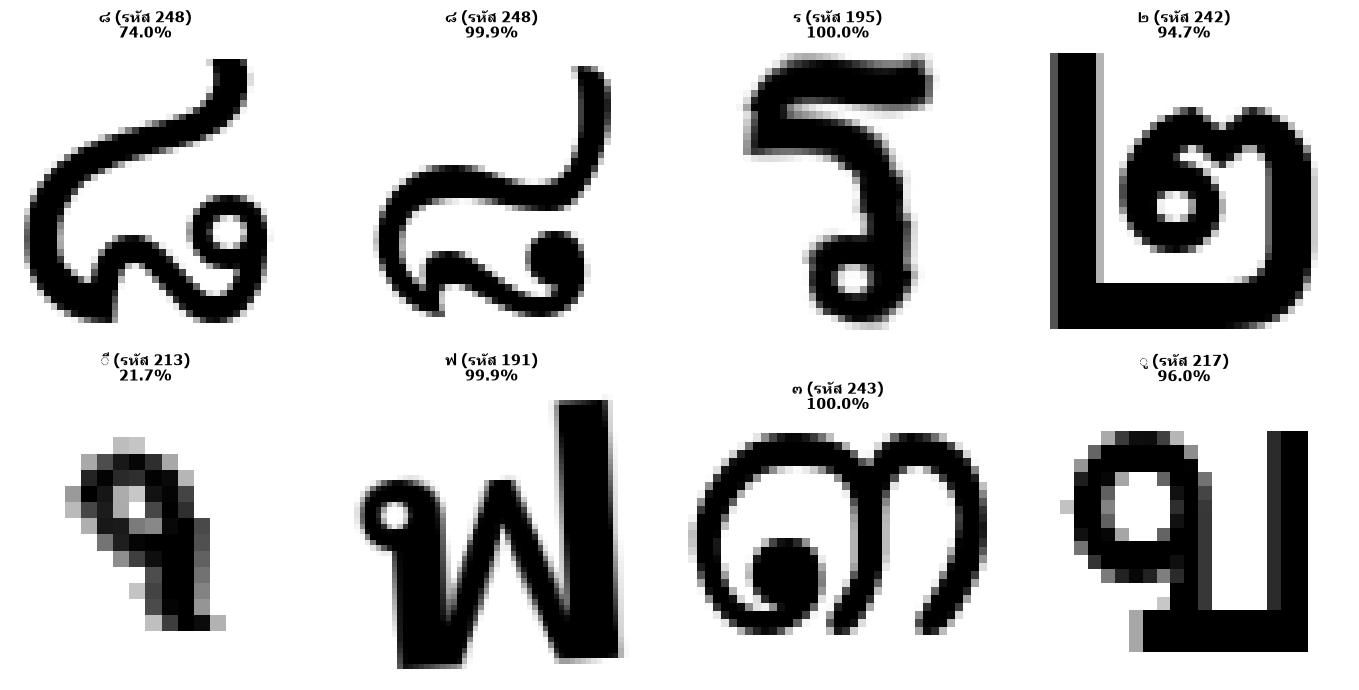

In [4]:
def show_demo(folder_path, n=8):
    if not os.path.exists(folder_path):
        print(f'ไม่พบโฟลเดอร์: {folder_path}')
        return
        
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = []
    for root, _, fnames in os.walk(folder_path):
        for f in fnames:
            if f.lower().endswith(valid_exts):
                files.append(os.path.join(root, f))
                
    if not files:
        print(f'ไม่พบรูปภาพใน: {folder_path}')
        return
        
    import random
    sample_files = random.sample(files, min(n, len(files)))
    
    cols = 4
    rows = int(np.ceil(len(sample_files) / cols))
    plt.figure(figsize=(cols * 3.5, rows * 3.5))
    
    for i, fp in enumerate(sample_files):
        res = predict_image(fp, show=False)
        img = Image.open(fp).convert('RGB')
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{res['char']} (รหัส {res['code']})\n{res['confidence']:.1f}%", fontsize=11, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# เรียกแสดงตัวอย่างการทำนาย
test_dir = 'synthetic_test_set' if os.path.exists('synthetic_test_set') else r'C:\Users\thewh\Downloads\Deep\synthetic_test_set'
show_demo(test_dir, n=8)
